In [1]:
# Install/upgrade required libraries
!pip install -q transformers datasets torch torchtext scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import re
import string
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
from datasets import load_dataset

# Using the maintained mirror repo (old "imdb" script-based loader is deprecated)
raw_data = load_dataset("stanfordnlp/imdb")

train_data = raw_data["train"].shuffle(seed=42)
test_data = raw_data["test"].shuffle(seed=42)

print("Train samples:", len(train_data))
print("Test samples:", len(test_data))
print("Sample review:", train_data[0]["text"][:300])
print("Label:", train_data[0]["label"])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train samples: 25000
Test samples: 25000
Sample review: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot 
Label: 1


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)          # remove html line breaks
    text = re.sub(r"[^a-z\s]", "", text)             # keep only letters
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_texts = [clean_text(t) for t in train_data["text"]]
train_labels = train_data["label"]

test_texts = [clean_text(t) for t in test_data["text"]]
test_labels = test_data["label"]

print(train_texts[0][:300])

there is no relation at all between fortier and profiler but the fact that both are police series about violent crimes profiler looks crispy fortier looks classic profiler plots are quite simple fortiers plot are far more complicated fortier looks more like prime suspect if we have to spot similarit


In [6]:
# Build a word-to-index vocabulary from the training set only (avoids test leakage)
def build_vocab(texts, max_vocab_size=20000, min_freq=2):
    counter = Counter()
    for t in texts:
        counter.update(t.split())

    # Reserve indices 0 and 1 for padding and unknown tokens
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.most_common(max_vocab_size):
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(train_texts, max_vocab_size=20000, min_freq=2)
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)

# Helper to turn a sentence into a list of token ids
def encode_text(text, vocab, max_len=200):
    tokens = text.split()
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens[:max_len]]
    if len(ids) < max_len:
        ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
    return ids

# Quick sanity check
sample_ids = encode_text(train_texts[0], vocab, max_len=200)
print("Encoded length:", len(sample_ids))
print("First 20 ids:", sample_ids[:20])

Vocabulary size: 20002
Encoded length: 200
First 20 ids: [47, 7, 56, 4328, 30, 31, 192, 1, 3, 1, 18, 2, 187, 12, 191, 23, 550, 201, 42, 1093]


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=200):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx], self.vocab, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


# Build train/test datasets
MAX_LEN = 200
BATCH_SIZE = 64

train_dataset = IMDBDataset(train_texts, train_labels, vocab, max_len=MAX_LEN)
test_dataset = IMDBDataset(test_texts, test_labels, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
sample_batch_x, sample_batch_y = next(iter(train_loader))
print("Batch input shape:", sample_batch_x.shape)   # [batch_size, max_len]
print("Batch label shape:", sample_batch_y.shape)    # [batch_size]
print("Sample labels:", sample_batch_y[:10])

Batch input shape: torch.Size([64, 200])
Batch label shape: torch.Size([64])
Sample labels: tensor([0, 1, 1, 0, 0, 1, 0, 1, 1, 1])


In [8]:
class VanillaRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, output_dim=2, padding_idx=0):
        super(VanillaRNNClassifier, self).__init__()

        # Embedding layer: turns integer IDs into dense vectors (this is the actual "vectorization")
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)

        # Vanilla RNN layer
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True, nonlinearity="tanh")

        # Final classification layer: hidden state -> 2 classes (pos/neg)
        self.fc = nn.Linear(hidden_dim, output_dim)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)                 # -> [batch_size, seq_len, embedding_dim]
        _, hidden = self.rnn(embedded)                # hidden -> [1, batch_size, hidden_dim]
        hidden = hidden.squeeze(0)                    # -> [batch_size, hidden_dim]
        hidden = self.dropout(hidden)
        out = self.fc(hidden)                         # -> [batch_size, 2]
        return out


# Instantiate model
EMBED_DIM = 100
HIDDEN_DIM = 128

rnn_model = VanillaRNNClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)
print(rnn_model)

# Quick sanity check with a real batch
sample_out = rnn_model(sample_batch_x.to(device))
print("Output shape:", sample_out.shape)  # should be [64, 2]

VanillaRNNClassifier(
  (embedding): Embedding(20002, 100, padding_idx=0)
  (rnn): RNN(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Output shape: torch.Size([64, 2])


In [9]:
import time

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, model_name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "test_acc": [], "test_f1": []}

    for epoch in range(epochs):
        start_time = time.time()

        # ---- Training ----
        model.train()
        total_loss, correct, total = 0, 0, 0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Gradient clipping - helps vanilla RNN especially (exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # ---- Evaluation ----
        test_acc, test_f1, _, _ = evaluate_model(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(test_f1)

        elapsed = time.time() - start_time
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f} | Time: {elapsed:.1f}s")

    return history


def evaluate_model(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return acc, f1, all_preds, all_labels

In [10]:
rnn_history = train_model(rnn_model, train_loader, test_loader, epochs=5, lr=0.001, model_name="Vanilla RNN")

[Vanilla RNN] Epoch 1/5 | Train Loss: 0.6984 | Train Acc: 0.5029 | Test Acc: 0.5058 | Test F1: 0.3314 | Time: 18.7s
[Vanilla RNN] Epoch 2/5 | Train Loss: 0.6916 | Train Acc: 0.5215 | Test Acc: 0.5078 | Test F1: 0.3376 | Time: 17.2s
[Vanilla RNN] Epoch 3/5 | Train Loss: 0.6918 | Train Acc: 0.5251 | Test Acc: 0.5064 | Test F1: 0.4020 | Time: 17.3s
[Vanilla RNN] Epoch 4/5 | Train Loss: 0.6882 | Train Acc: 0.5334 | Test Acc: 0.5052 | Test F1: 0.6141 | Time: 18.0s
[Vanilla RNN] Epoch 5/5 | Train Loss: 0.6763 | Train Acc: 0.5540 | Test Acc: 0.5082 | Test F1: 0.6273 | Time: 17.7s


In [11]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, output_dim=2, padding_idx=0):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, cell) = self.lstm(embedded)   # LSTM returns hidden AND cell state
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        return self.fc(hidden)


class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, output_dim=2, padding_idx=0):
        super(GRUClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)            # GRU only returns hidden state (no cell state)
        hidden = hidden.squeeze(0)
        hidden = self.dropout(hidden)
        return self.fc(hidden)


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, output_dim=2, padding_idx=0):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        # bidirectional doubles hidden dim (forward + backward concatenated)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, cell) = self.lstm(embedded)
        # hidden shape: [2, batch_size, hidden_dim] -> concat forward & backward final states
        hidden = torch.cat((hidden[0], hidden[1]), dim=1)   # -> [batch_size, hidden_dim*2]
        hidden = self.dropout(hidden)
        return self.fc(hidden)


# Instantiate all three
lstm_model = LSTMClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)
gru_model = GRUClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)
bilstm_model = BiLSTMClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)

print("LSTM params:", sum(p.numel() for p in lstm_model.parameters()))
print("GRU params:", sum(p.numel() for p in gru_model.parameters()))
print("BiLSTM params:", sum(p.numel() for p in bilstm_model.parameters()))

LSTM params: 2118218
GRU params: 2088778
BiLSTM params: 2236234


In [12]:
lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=5, lr=0.001, model_name="LSTM")

[LSTM] Epoch 1/5 | Train Loss: 0.6938 | Train Acc: 0.5018 | Test Acc: 0.5124 | Test F1: 0.3188 | Time: 27.0s
[LSTM] Epoch 2/5 | Train Loss: 0.6849 | Train Acc: 0.5466 | Test Acc: 0.5546 | Test F1: 0.4015 | Time: 22.5s
[LSTM] Epoch 3/5 | Train Loss: 0.6624 | Train Acc: 0.5931 | Test Acc: 0.6493 | Test F1: 0.6274 | Time: 22.3s
[LSTM] Epoch 4/5 | Train Loss: 0.6058 | Train Acc: 0.6928 | Test Acc: 0.6565 | Test F1: 0.6131 | Time: 21.1s
[LSTM] Epoch 5/5 | Train Loss: 0.5678 | Train Acc: 0.7167 | Test Acc: 0.6816 | Test F1: 0.6429 | Time: 21.8s


In [13]:
gru_history = train_model(gru_model, train_loader, test_loader, epochs=5, lr=0.001, model_name="GRU")

[GRU] Epoch 1/5 | Train Loss: 0.6942 | Train Acc: 0.5137 | Test Acc: 0.5177 | Test F1: 0.2840 | Time: 20.5s
[GRU] Epoch 2/5 | Train Loss: 0.6802 | Train Acc: 0.5552 | Test Acc: 0.5220 | Test F1: 0.1898 | Time: 21.7s
[GRU] Epoch 3/5 | Train Loss: 0.6265 | Train Acc: 0.6712 | Test Acc: 0.6602 | Test F1: 0.6812 | Time: 19.5s
[GRU] Epoch 4/5 | Train Loss: 0.5391 | Train Acc: 0.7533 | Test Acc: 0.7618 | Test F1: 0.7483 | Time: 20.2s
[GRU] Epoch 5/5 | Train Loss: 0.4062 | Train Acc: 0.8249 | Test Acc: 0.8144 | Test F1: 0.8172 | Time: 20.0s


In [21]:
bilstm_model2 = BiLSTMClassifier(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)
bilstm_history2 = train_model(bilstm_model2, train_loader, test_loader, epochs=10, lr=0.0007, model_name="BiLSTM (10 epochs)")

[BiLSTM (10 epochs)] Epoch 1/10 | Train Loss: 0.6467 | Train Acc: 0.6167 | Test Acc: 0.6386 | Test F1: 0.5507 | Time: 27.3s
[BiLSTM (10 epochs)] Epoch 2/10 | Train Loss: 0.5552 | Train Acc: 0.7276 | Test Acc: 0.7418 | Test F1: 0.7595 | Time: 25.3s
[BiLSTM (10 epochs)] Epoch 3/10 | Train Loss: 0.4543 | Train Acc: 0.7961 | Test Acc: 0.7942 | Test F1: 0.8030 | Time: 24.1s
[BiLSTM (10 epochs)] Epoch 4/10 | Train Loss: 0.3815 | Train Acc: 0.8393 | Test Acc: 0.7465 | Test F1: 0.7584 | Time: 24.0s
[BiLSTM (10 epochs)] Epoch 5/10 | Train Loss: 0.3158 | Train Acc: 0.8748 | Test Acc: 0.8047 | Test F1: 0.8024 | Time: 24.0s
[BiLSTM (10 epochs)] Epoch 6/10 | Train Loss: 0.2566 | Train Acc: 0.9023 | Test Acc: 0.8293 | Test F1: 0.8253 | Time: 24.8s
[BiLSTM (10 epochs)] Epoch 7/10 | Train Loss: 0.2063 | Train Acc: 0.9231 | Test Acc: 0.8274 | Test F1: 0.8278 | Time: 24.1s
[BiLSTM (10 epochs)] Epoch 8/10 | Train Loss: 0.1652 | Train Acc: 0.9395 | Test Acc: 0.8115 | Test F1: 0.7944 | Time: 23.9s
[BiLSTM 

In [22]:
import math

class PositionalEncoding(nn.Module):
    """Injects order information into embeddings, since attention has no built-in sense of sequence order."""
    def __init__(self, embedding_dim, max_len=200):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, embedding_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embedding_dim, 2).float() * (-math.log(10000.0) / embedding_dim))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # -> [1, max_len, embedding_dim]

        self.register_buffer("pe", pe)  # not a trainable parameter, just fixed math

    def forward(self, x):
        # x shape: [batch_size, seq_len, embedding_dim]
        return x + self.pe[:, :x.size(1), :]


class CustomTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=4, num_layers=2,
                 ff_dim=256, output_dim=2, max_len=200, padding_idx=0, dropout=0.3):
        super(CustomTransformerClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.pos_encoder = PositionalEncoding(embedding_dim, max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embedding_dim, output_dim)
        self.padding_idx = padding_idx

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        padding_mask = (x == self.padding_idx)  # True where padded -> tells attention to ignore these

        embedded = self.embedding(x)                       # -> [batch, seq_len, embed_dim]
        embedded = self.pos_encoder(embedded)

        encoded = self.transformer_encoder(embedded, src_key_padding_mask=padding_mask)
        # encoded shape: [batch, seq_len, embed_dim]

        # Mean-pool over non-padded tokens only (standard approach when there's no [CLS] token)
        mask = (~padding_mask).unsqueeze(-1).float()       # 1 for real tokens, 0 for padding
        summed = (encoded * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        pooled = summed / counts                            # -> [batch, embed_dim]

        pooled = self.dropout(pooled)
        return self.fc(pooled)


# Instantiate
custom_transformer = CustomTransformerClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    num_heads=4,
    num_layers=2,
    ff_dim=256,
    max_len=MAX_LEN
).to(device)

print(custom_transformer)
print("Custom Transformer params:", sum(p.numel() for p in custom_transformer.parameters()))

# Sanity check
sample_out = custom_transformer(sample_batch_x.to(device))
print("Output shape:", sample_out.shape)  # should be [64, 2]

CustomTransformerClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Custom Transformer params: 2825474
Output shape: torch.Size(

In [23]:
# Transformers
custom_transformer_history = train_model(
    custom_transformer, train_loader, test_loader,
    epochs=5, lr=0.0005, model_name="Custom Transformer"
)

[Custom Transformer] Epoch 1/5 | Train Loss: 0.5409 | Train Acc: 0.7076 | Test Acc: 0.7938 | Test F1: 0.8064 | Time: 28.1s
[Custom Transformer] Epoch 2/5 | Train Loss: 0.3974 | Train Acc: 0.8194 | Test Acc: 0.8193 | Test F1: 0.8328 | Time: 31.2s
[Custom Transformer] Epoch 3/5 | Train Loss: 0.3269 | Train Acc: 0.8606 | Test Acc: 0.8360 | Test F1: 0.8333 | Time: 28.6s
[Custom Transformer] Epoch 4/5 | Train Loss: 0.2806 | Train Acc: 0.8854 | Test Acc: 0.8414 | Test F1: 0.8442 | Time: 28.8s
[Custom Transformer] Epoch 5/5 | Train Loss: 0.2358 | Train Acc: 0.9062 | Test Acc: 0.8391 | Test F1: 0.8459 | Time: 30.0s


In [31]:
# Collect final (best) results per model
results = {
    "Vanilla RNN": rnn_history,
    "LSTM": lstm_history,
    "GRU": gru_history,
    "BiLSTM": bilstm_history2,
    "Custom Transformer": custom_transformer_history,
}


In [34]:
summary_rows = []
for name, hist in results.items():
    best_idx = np.argmax(hist["test_acc"])
    summary_rows.append({
        "Model": name,
        "Best Test Accuracy": hist["test_acc"][best_idx],
        "Best Test F1": hist["test_f1"][best_idx],
        "Best Epoch": best_idx + 1,
        "Final Train Accuracy": hist["train_acc"][-1],
        "Params": None  # filled in below
    })

# Add parameter counts for context
param_counts = {
    "Vanilla RNN": sum(p.numel() for p in rnn_model.parameters()),
    "LSTM": sum(p.numel() for p in lstm_model.parameters()),
    "GRU": sum(p.numel() for p in gru_model.parameters()),
    "BiLSTM": sum(p.numel() for p in bilstm_model.parameters()),
    "Custom Transformer": sum(p.numel() for p in custom_transformer.parameters()),
}
for row in summary_rows:
    row["Params"] = param_counts[row["Model"]]

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("Best Test Accuracy").reset_index(drop=True)
summary_df

,Model,Best Test Accuracy,Best Test F1,Best Epoch,Final Train Accuracy,Params
0,Vanilla RNN,0.50820,0.627277,5,0.55404,2029898
1,LSTM,0.68160,0.642921,5,0.71668,2118218
2,GRU,0.81440,0.817164,5,0.82492,2088778
3,BiLSTM,0.83488,0.834893,10,0.96980,2236234
4,Custom Transformer,0.84136,0.844190,4,0.90616,2825474


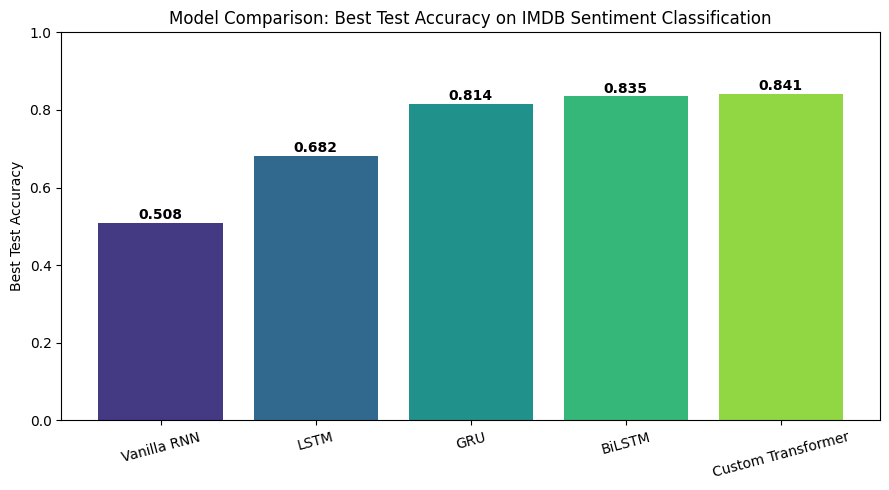

In [35]:
plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", len(summary_df))
bars = plt.bar(summary_df["Model"], summary_df["Best Test Accuracy"], color=colors)

for bar, acc in zip(bars, summary_df["Best Test Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f"{acc:.3f}", ha="center", fontweight="bold")

plt.ylim(0, 1.0)
plt.ylabel("Best Test Accuracy")
plt.title("Model Comparison: Best Test Accuracy on IMDB Sentiment Classification")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

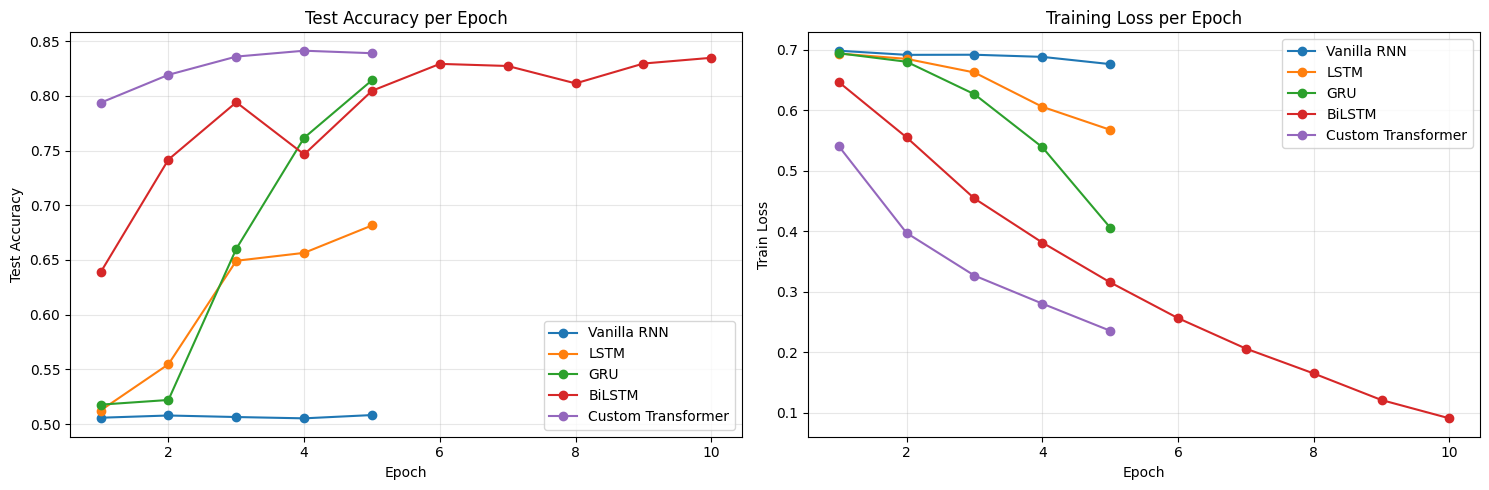

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, hist in results.items():
    epochs_range = range(1, len(hist["test_acc"]) + 1)
    axes[0].plot(epochs_range, hist["test_acc"], marker="o", label=name)
    axes[1].plot(epochs_range, hist["train_loss"], marker="o", label=name)

axes[0].set_title("Test Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Training Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Train Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

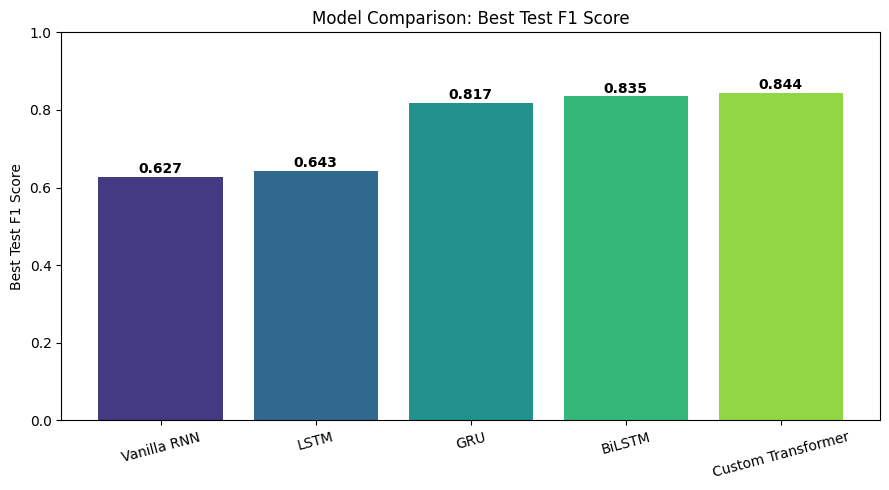


Final Ranked Results:

             Model  Best Test Accuracy  Best Test F1  Best Epoch  Final Train Accuracy  Params
       Vanilla RNN             0.50820      0.627277           5               0.55404 2029898
              LSTM             0.68160      0.642921           5               0.71668 2118218
               GRU             0.81440      0.817164           5               0.82492 2088778
            BiLSTM             0.83488      0.834893          10               0.96980 2236234
Custom Transformer             0.84136      0.844190           4               0.90616 2825474


In [37]:
plt.figure(figsize=(9, 5))
bars = plt.bar(summary_df["Model"], summary_df["Best Test F1"], color=colors)

for bar, f1 in zip(bars, summary_df["Best Test F1"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f"{f1:.3f}", ha="center", fontweight="bold")

plt.ylim(0, 1.0)
plt.ylabel("Best Test F1 Score")
plt.title("Model Comparison: Best Test F1 Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=150)
plt.show()

print("\nFinal Ranked Results:\n")
print(summary_df.to_string(index=False))